# Part B — Predictive Modeling (Titanic)

Continuation from the cleaned dataset produced in Part A (`titanic.csv`).                        
Covers points : stratified split, leakage-safe preprocessing, three classifiers,
full evaluation, imbalance handling comparison, Random Forest tuning with OOB score,
a fare regression side-task, a combined comparison table, and saving/reloading the
best complete pipeline for deployment on raw input.


In [ ]:
# ============================================================
# PART B — PREDICTIVE MODELING 
# Continuation from the cleaned Titanic dataset (titanic.csv)
# ============================================================

# ------------------------------------------------------------
# 0. IMPORTS
# ------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import joblib

# ------------------------------------------------------------
# LOAD CLEANED DATA (produced in Part A / Task 1-6)
# ------------------------------------------------------------
DATA_FILE = "titanic.csv"
df = pd.read_csv(DATA_FILE)

required_columns = ["survived", "sex", "embarked", "pclass",
                     "age", "sibsp", "parch", "fare"]
missing_required = [c for c in required_columns if c not in df.columns]
if missing_required:
    raise ValueError(
        f"The following required columns are missing from {DATA_FILE}: {missing_required}"
    )

print("Dataset shape:", df.shape)

Dataset shape: (889, 14)


## CLASS BALANCE + STRATIFIED TRAIN/TEST SPLIT


In [6]:
# --- Class balance (needed to justify stratification) ---
class_counts = df["survived"].value_counts().sort_index()
class_percentages = df["survived"].value_counts(normalize=True).sort_index().mul(100)

balance_table = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages.round(2),
})
balance_table.index = ["Not Survived (0)", "Survived (1)"]
print("\n=== Survival Class Balance ===")
print(balance_table)
print("="*50)
print("""
Stratification justification:
The 'survived' classes are not perfectly balanced (see table above). A plain
random train/test split could, by chance, produce noticeably different
survived/not-survived proportions between the training and test sets, which
would make test-set evaluation less representative of the true class
distribution and could bias metrics such as recall for the minority class.
A stratified split (stratify=y) preserves approximately the same class
proportions in both the training and test sets, so evaluation results are
more reliable and comparable across models.
""")
print("="*50)
# --- Classification features and target ---
classification_features = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
X = df[classification_features].copy()
y = df["survived"].copy()

# --- Stratified split — done BEFORE any preprocessing/imputation/encoding/scaling ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("Training rows:", X_train.shape[0], "| Testing rows:", X_test.shape[0])
print("="*50)
print("Training target distribution:\n", y_train.value_counts(normalize=True).sort_index())
print("="*50)
print("Testing target distribution:\n", y_test.value_counts(normalize=True).sort_index())


=== Survival Class Balance ===
                  Count  Percentage
Not Survived (0)    549       61.75
Survived (1)        340       38.25

Stratification justification:
The 'survived' classes are not perfectly balanced (see table above). A plain
random train/test split could, by chance, produce noticeably different
survived/not-survived proportions between the training and test sets, which
would make test-set evaluation less representative of the true class
distribution and could bias metrics such as recall for the minority class.
A stratified split (stratify=y) preserves approximately the same class
proportions in both the training and test sets, so evaluation results are
more reliable and comparable across models.

Training rows: 711 | Testing rows: 178
Training target distribution:
 survived
0    0.61744
1    0.38256
Name: proportion, dtype: float64
Testing target distribution:
 survived
0    0.617978
1    0.382022
Name: proportion, dtype: float64


##  PREPROCESSING (fit on TRAIN only, via ColumnTransformer)


In [8]:
numeric_features = ["pclass", "age", "sibsp", "parch", "fare"]
categorical_features = ["sex", "embarked"]

# Numeric: median imputation (robust to outliers/skew, e.g. fare) + StandardScaler
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Categorical: most-frequent imputation + One-Hot Encoding
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])

# Because preprocessor lives INSIDE each Pipeline below, calling pipeline.fit(X_train, y_train)
# fits the imputer/encoder/scaler ONLY on X_train. Calling pipeline.predict(X_test) or
# pipeline.transform(X_test) only ever calls .transform() on the already-fitted steps —
# the test split never influences the fitted imputer/encoder/scaler parameters.

## TRAIN THREE CLASSIFIERS ON THE SAME SPLIT


Logistic Regression: training complete
Decision Tree: training complete
Random Forest: training complete


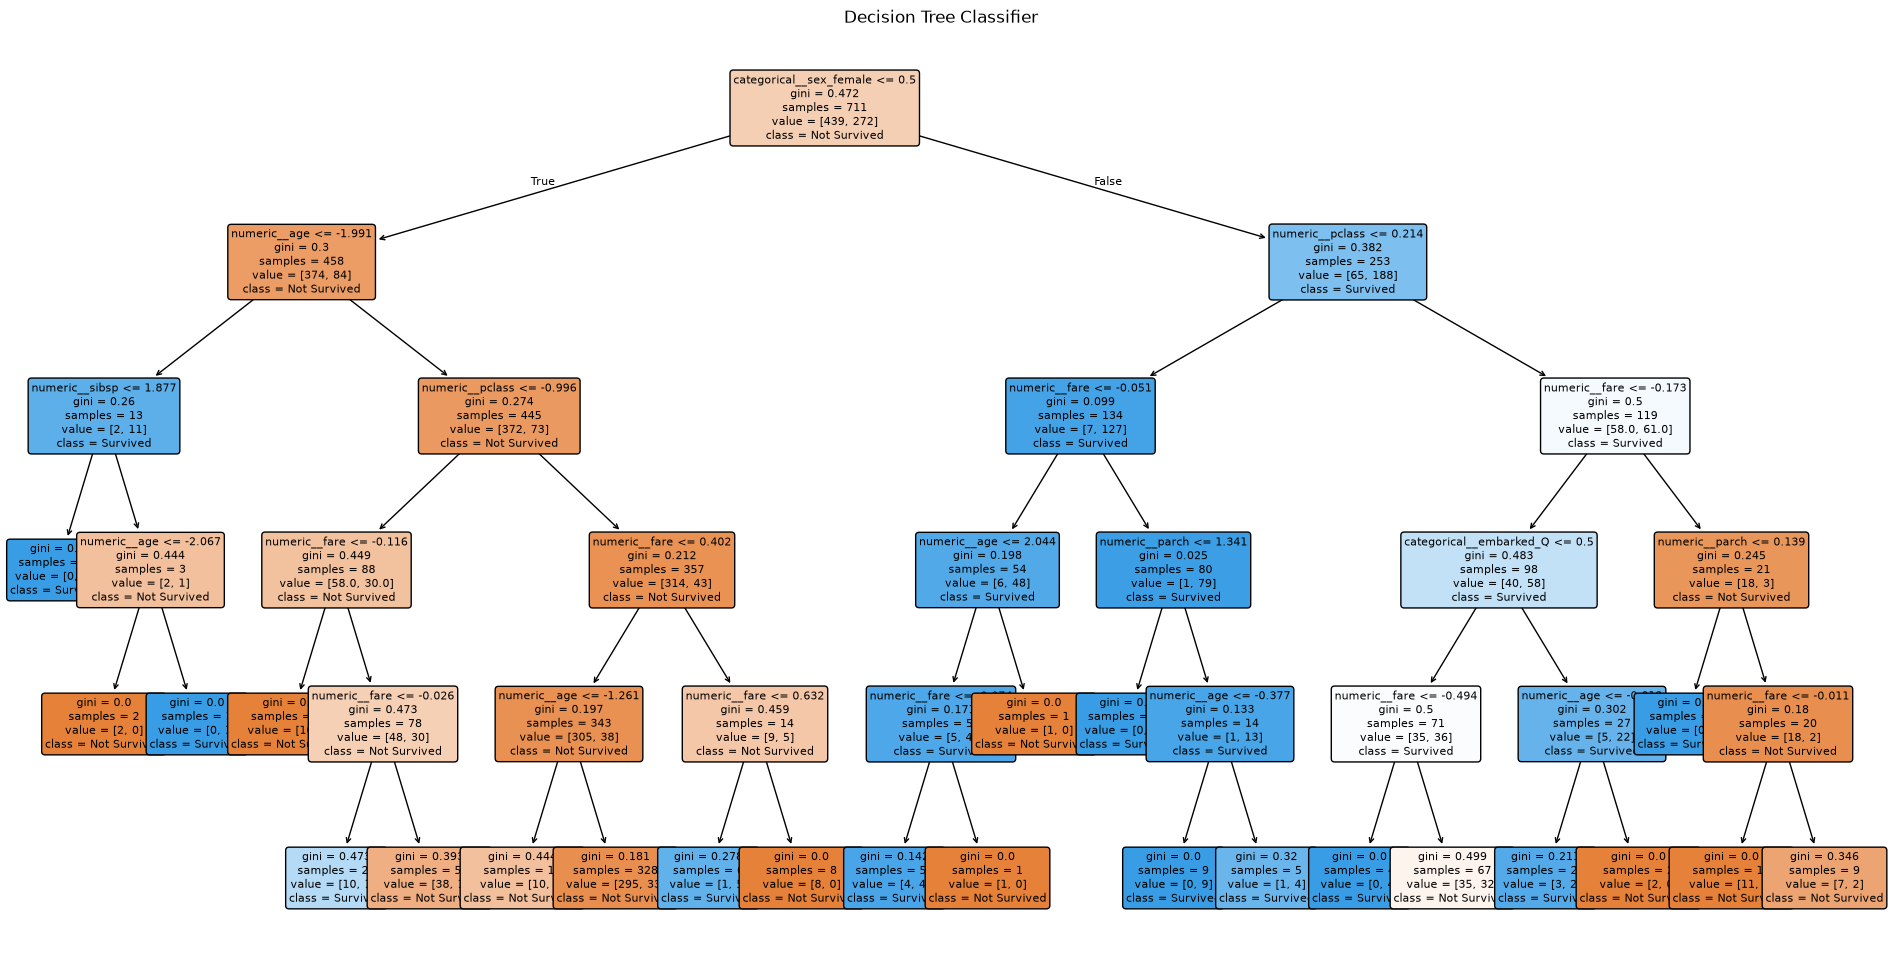

In [9]:
logistic_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42)),
])

decision_tree_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42, max_depth=5)),
])

random_forest_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(n_estimators=200, random_state=42)),
])

models = {
    "Logistic Regression": logistic_pipeline,
    "Decision Tree": decision_tree_pipeline,
    "Random Forest": random_forest_pipeline,
}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{model_name}: training complete")

# --- Render the Decision Tree with feature names + class names ---
tree_model = models["Decision Tree"]
tree_preprocessor = tree_model.named_steps["preprocessing"]
tree_classifier = tree_model.named_steps["model"]
feature_names = tree_preprocessor.get_feature_names_out()

plt.figure(figsize=(24, 12))
plot_tree(
    tree_classifier,
    feature_names=feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    fontsize=8,
)
plt.title("Decision Tree Classifier")
plt.show()

##  EVALUATE ALL THREE MODELS + COMPARISON TABLE



=== Logistic Regression ===
Confusion Matrix:
 [[97 13]
 [21 47]]
Accuracy=0.8090  Precision=0.7833  Recall=0.6912  F1=0.7344  AUC=0.8610

=== Decision Tree ===
Confusion Matrix:
 [[98 12]
 [30 38]]
Accuracy=0.7640  Precision=0.7600  Recall=0.5588  F1=0.6441  AUC=0.8374

=== Random Forest ===
Confusion Matrix:
 [[95 15]
 [19 49]]
Accuracy=0.8090  Precision=0.7656  Recall=0.7206  F1=0.7424  AUC=0.8196


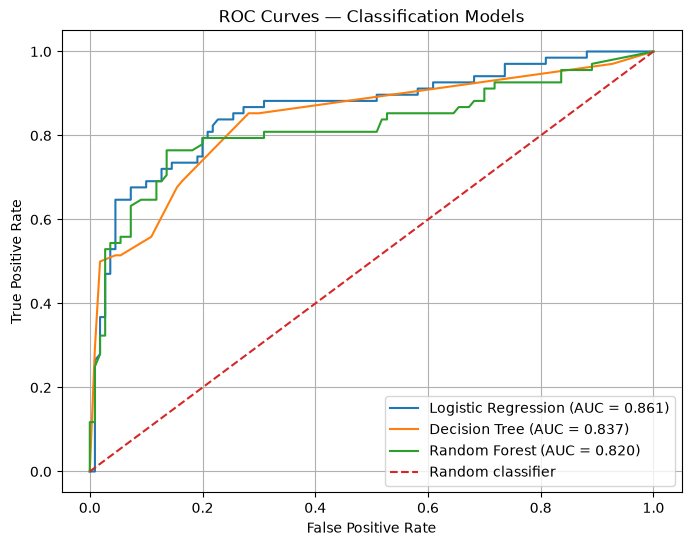

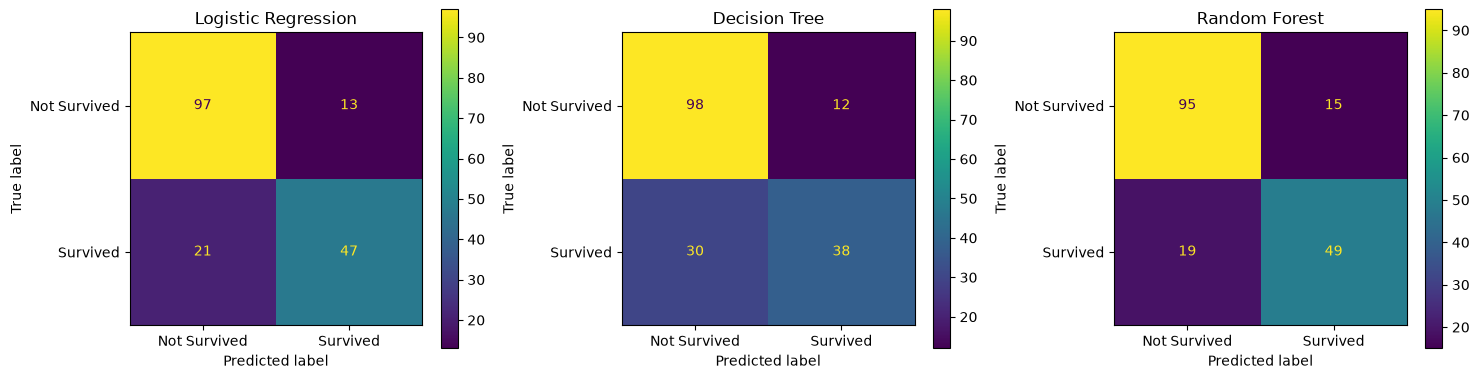


=== Classification Comparison Table ===
                 Model  Accuracy  Precision  Recall      F1     AUC
0  Logistic Regression     0.809     0.7833  0.6912  0.7344  0.8610
1        Decision Tree     0.764     0.7600  0.5588  0.6441  0.8374
2        Random Forest     0.809     0.7656  0.7206  0.7424  0.8196


In [10]:
classification_results = []
plt.figure(figsize=(8, 6))

for model_name, model in models.items():
    y_pred = model.predict(X_test)
    y_probability = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_probability)

    classification_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc,
    })

    cm = confusion_matrix(y_test, y_pred)
    print(f"\n=== {model_name} ===")
    print("Confusion Matrix:\n", cm)
    print(f"Accuracy={accuracy:.4f}  Precision={precision:.4f}  "
          f"Recall={recall:.4f}  F1={f1:.4f}  AUC={auc:.4f}")

    fpr, tpr, _ = roc_curve(y_test, y_probability)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Classification Models")
plt.legend()
plt.grid(True)
plt.show()

# --- Confusion matrices side by side ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (model_name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=["Not Survived", "Survived"])
    disp.plot(ax=ax, values_format="d")
    ax.set_title(model_name)
plt.tight_layout()
plt.show()

# --- Single comparison table: Accuracy | Precision | Recall | F1 | AUC ---
classification_comparison = pd.DataFrame(classification_results)
classification_comparison[["Accuracy", "Precision", "Recall", "F1", "AUC"]] = (
    classification_comparison[["Accuracy", "Precision", "Recall", "F1", "AUC"]].round(4)
)
print("\n=== Classification Comparison Table ===")
print(classification_comparison)

## IMBALANCE HANDLING COMPARISON (Logistic Regression)


In [ ]:
# Class balance already reported in  (balance_table).
# Three variants below, all trained on the SAME X_train/y_train and
# evaluated on the SAME X_test/y_test.

# --- (a) Baseline: no imbalance handling ---
baseline_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42)),
])
baseline_pipeline.fit(X_train, y_train)
baseline_pred = baseline_pipeline.predict(X_test)
baseline_precision = precision_score(y_test, baseline_pred, zero_division=0)
baseline_recall = recall_score(y_test, baseline_pred, zero_division=0)
baseline_f1 = f1_score(y_test, baseline_pred, zero_division=0)

# --- (b) class_weight="balanced" ---
balanced_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
])
balanced_pipeline.fit(X_train, y_train)
balanced_pred = balanced_pipeline.predict(X_test)
balanced_precision = precision_score(y_test, balanced_pred, zero_division=0)
balanced_recall = recall_score(y_test, balanced_pred, zero_division=0)
balanced_f1 = f1_score(y_test, balanced_pred, zero_division=0)

# --- (c) SMOTE — applied to the TRAINING FOLD ONLY (inside the fit pipeline) ---
# imblearn's Pipeline ensures SMOTE only runs during .fit() on training data;
# .predict() on X_test skips the SMOTE step entirely, so the test set is
# never oversampled or otherwise touched by SMOTE — no leakage.
smote_pipeline = ImbPipeline([
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000, random_state=42)),
])
smote_pipeline.fit(X_train, y_train)
smote_pred = smote_pipeline.predict(X_test)
smote_precision = precision_score(y_test, smote_pred, zero_division=0)
smote_recall = recall_score(y_test, smote_pred, zero_division=0)
smote_f1 = f1_score(y_test, smote_pred, zero_division=0)

imbalance_results = pd.DataFrame([
    {"Strategy": "Baseline / No Handling", "Precision": baseline_precision,
     "Recall": baseline_recall, "F1": baseline_f1},
    {"Strategy": "class_weight='balanced'", "Precision": balanced_precision,
     "Recall": balanced_recall, "F1": balanced_f1},
    {"Strategy": "SMOTE", "Precision": smote_precision,
     "Recall": smote_recall, "F1": smote_f1},
])
imbalance_results[["Precision", "Recall", "F1"]] = (
    imbalance_results[["Precision", "Recall", "F1"]].round(4)
)
print("\n=== Imbalance Handling Comparison ===")
print(imbalance_results)
print("="*50)

# --- Written conclusion generated from the ACTUAL results (no hard-coded claim) ---
best_imbalance_row = imbalance_results.loc[imbalance_results["F1"].idxmax()]
print(f"""
Imbalance conclusion:
The survived/not-survived classes are not perfectly balanced (see 
class-balance table). Among the three Logistic Regression variants evaluated
on the identical test set, "{best_imbalance_row['Strategy']}" produced the
highest F1 score of {best_imbalance_row['F1']:.4f} (precision
{best_imbalance_row['Precision']:.4f}, recall {best_imbalance_row['Recall']:.4f}).
F1 is used as the primary comparison metric because it balances precision and
recall into one number, which matters here since the baseline model can favor
the majority class at the expense of recall on the minority class. The
strategy that best trades off these competing errors on this test set is the
one identified above; this conclusion is based on the actual run's numbers
rather than an assumed result.
""")


=== Imbalance Handling Comparison ===
                  Strategy  Precision  Recall      F1
0   Baseline / No Handling     0.7833  0.6912  0.7344
1  class_weight='balanced'     0.7183  0.7500  0.7338
2                    SMOTE     0.7353  0.7353  0.7353

Imbalance conclusion:
The survived/not-survived classes are not perfectly balanced (see 
class-balance table). Among the three Logistic Regression variants evaluated
on the identical test set, "SMOTE" produced the
highest F1 score of 0.7353 (precision
0.7353, recall 0.7353).
F1 is used as the primary comparison metric because it balances precision and
recall into one number, which matters here since the baseline model can favor
the majority class at the expense of recall on the minority class. The
strategy that best trades off these competing errors on this test set is the
one identified above; this conclusion is based on the actual run's numbers
rather than an assumed result.



##  GRIDSEARCHCV ON RANDOM FOREST + OOB SCORE


In [14]:
# oob_score=True MUST be passed at construction time, otherwise oob_score_
# will not be available on the fitted/refitted estimator.
rf_for_grid = RandomForestClassifier(oob_score=True, random_state=42, n_jobs=-1)

rf_grid_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", rf_for_grid),
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 5, 10],
    "model__max_features": ["sqrt", "log2"],
}

grid_search = GridSearchCV(
    estimator=rf_grid_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    refit=True,
)
grid_search.fit(X_train, y_train)

best_rf_pipeline = grid_search.best_estimator_
best_rf_model = best_rf_pipeline.named_steps["model"]

print("\n=== Random Forest GridSearchCV ===")
print("Best parameters:", grid_search.best_params_)
print("Best CV accuracy:", round(grid_search.best_score_, 4))
print("OOB score:", round(best_rf_model.oob_score_, 4))

# Test-set performance of the tuned Random Forest
tuned_rf_pred = best_rf_pipeline.predict(X_test)
tuned_rf_probability = best_rf_pipeline.predict_proba(X_test)[:, 1]
print("Tuned RF Test — Accuracy:", round(accuracy_score(y_test, tuned_rf_pred), 4),
      "| Precision:", round(precision_score(y_test, tuned_rf_pred, zero_division=0), 4),
      "| Recall:", round(recall_score(y_test, tuned_rf_pred, zero_division=0), 4),
      "| F1:", round(f1_score(y_test, tuned_rf_pred, zero_division=0), 4),
      "| AUC:", round(roc_auc_score(y_test, tuned_rf_probability), 4))


=== Random Forest GridSearchCV ===
Best parameters: {'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__n_estimators': 200}
Best CV accuracy: 0.82
OOB score: 0.8214
Tuned RF Test — Accuracy: 0.8315 | Precision: 0.8654 | Recall: 0.6618 | F1: 0.75 | AUC: 0.8389


## REGRESSION SIDE-TASK: PREDICT FARE



=== Regression Results (predicting fare) ===
MAE=21.0986  RMSE=41.7021  R²=0.3482  Adjusted R²=0.3091


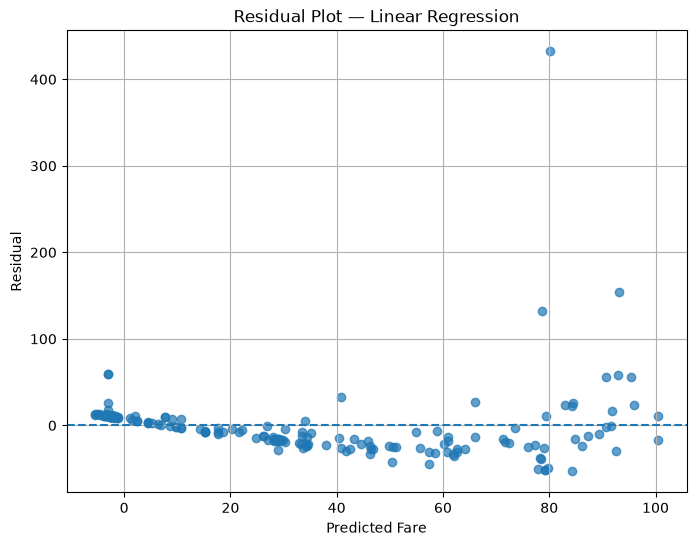


Residual std — lower-predicted-fare half: 13.1415
Residual std — higher-predicted-fare half: 56.8846
Ratio (high/low): 4.3286

Heteroscedasticity conclusion (verify against the plot above):
The residual spread differs substantially between the lower- and 
higher-predicted-fare halves of the test set (ratio of 
4.33), and the residual plot above should be checked
 for a funnel-like pattern. This is evidence of heteroscedasticity — 
the variance of the residuals is not constant across predicted fare.

NOTE: This automated ratio is a supporting signal only. The final written
statement in your submission should match what is actually visible in the
residual plot produced above (e.g. a funnel/cone shape widening as predicted
fare increases would indicate heteroscedasticity even if the ratio above is
borderline).



In [16]:
# fare is the target and is EXCLUDED from the predictors.
regression_features = ["pclass", "sex", "age", "sibsp", "parch", "embarked", "survived"]
regression_target = "fare"

regression_data = df[regression_features + [regression_target]].copy()

# A regression model cannot train with a missing target; only rows with a
# missing fare are dropped. Missing predictor values are handled by the
# preprocessing pipeline below.
regression_data = regression_data.dropna(subset=[regression_target])

X_reg = regression_data[regression_features].copy()
y_reg = regression_data[regression_target].copy()

# Split first, preprocess after (same leakage-avoidance rule as classification)
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=42
)

reg_numeric_features = ["pclass", "age", "sibsp", "parch", "survived"]
reg_categorical_features = ["sex", "embarked"]

reg_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
reg_categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
reg_preprocessor = ColumnTransformer([
    ("numeric", reg_numeric_pipeline, reg_numeric_features),
    ("categorical", reg_categorical_pipeline, reg_categorical_features),
])

regression_pipeline = Pipeline([
    ("preprocessing", reg_preprocessor),
    ("model", LinearRegression()),
])
regression_pipeline.fit(X_reg_train, y_reg_train)

y_reg_pred = regression_pipeline.predict(X_reg_test)

mae = mean_absolute_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
r2 = r2_score(y_reg_test, y_reg_pred)

n = len(y_reg_test)
reg_transformed_X_test = regression_pipeline.named_steps["preprocessing"].transform(X_reg_test)
p = reg_transformed_X_test.shape[1]
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("\n=== Regression Results (predicting fare) ===")
print(f"MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}  Adjusted R²={adjusted_r2:.4f}")

# --- Residual plot ---
residuals = y_reg_test - y_reg_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_reg_pred, residuals, alpha=0.7)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Fare")
plt.ylabel("Residual")
plt.title("Residual Plot — Linear Regression")
plt.grid(True)
plt.show()

# --- Heteroscedasticity check computed from the actual residuals, not assumed ---
# Split predictions into low/high halves by predicted value and compare the
# spread (std) of residuals in each half as an objective signal to accompany
# the visual inspection of the plot above.
sorted_idx = np.argsort(y_reg_pred)
half = len(sorted_idx) // 2
low_half_std = residuals.to_numpy()[sorted_idx[:half]].std()
high_half_std = residuals.to_numpy()[sorted_idx[half:]].std()
spread_ratio = high_half_std / low_half_std if low_half_std > 0 else np.nan

print(f"\nResidual std — lower-predicted-fare half: {low_half_std:.4f}")
print(f"Residual std — higher-predicted-fare half: {high_half_std:.4f}")
print(f"Ratio (high/low): {spread_ratio:.4f}")

if spread_ratio > 1.5 or spread_ratio < (1 / 1.5):
    heteroscedasticity_conclusion = (
        "The residual spread differs substantially between the lower- and \n"
        "higher-predicted-fare halves of the test set (ratio of \n"
        f"{spread_ratio:.2f}), and the residual plot above should be checked\n "
        "for a funnel-like pattern. This is evidence of heteroscedasticity — \n"
        "the variance of the residuals is not constant across predicted fare."
    )
else:
    heteroscedasticity_conclusion = (
        "The residual spread is broadly similar between the lower- and \n"
        "higher-predicted-fare halves of the test set (ratio of \n"
        f"{spread_ratio:.2f}), and the residual plot above should be checked \n"
        "to confirm it does not show a funnel-like pattern. This does not \n"
        "provide strong evidence of heteroscedasticity — the residual \n"
        "variance appears roughly constant across predicted fare."
    )

print("\nHeteroscedasticity conclusion (verify against the plot above):")
print(heteroscedasticity_conclusion)
print("""
NOTE: This automated ratio is a supporting signal only. The final written
statement in your submission should match what is actually visible in the
residual plot produced above (e.g. a funnel/cone shape widening as predicted
fare increases would indicate heteroscedasticity even if the ratio above is
borderline).
""")

## FINAL MODEL COMPARISON TABLE + RECOMMENDATION


In [17]:
# Classification metrics, renamed to make the "separate metric group" explicit
final_classification = classification_comparison.rename(columns={
    "Accuracy": "Classification Accuracy",
    "Precision": "Classification Precision",
    "Recall": "Classification Recall",
    "F1": "Classification F1",
    "AUC": "Classification AUC",
})

regression_metrics = pd.DataFrame({
    "Regression MAE": [mae],
    "Regression RMSE": [rmse],
    "Regression R²": [r2],
    "Regression Adjusted R²": [adjusted_r2],
}).round(4)

print("\n=== FINAL COMPARISON — Classification metrics (own group) ===")
print(final_classification[[
    "Model", "Classification Accuracy", "Classification Precision",
    "Classification Recall", "Classification F1", "Classification AUC",
]])

print("\n=== FINAL COMPARISON — Regression metrics (own group, not comparable to classification) ===")
print(regression_metrics)

# Combined table with the two metric groups kept visually distinct
combined_comparison = final_classification.copy()
combined_comparison["Regression MAE"] = np.nan
combined_comparison["Regression RMSE"] = np.nan
combined_comparison["Regression R²"] = np.nan
combined_comparison["Regression Adjusted R²"] = np.nan

regression_row = pd.DataFrame([{
    "Model": "Linear Regression",
    "Classification Accuracy": np.nan,
    "Classification Precision": np.nan,
    "Classification Recall": np.nan,
    "Classification F1": np.nan,
    "Classification AUC": np.nan,
    "Regression MAE": mae,
    "Regression RMSE": rmse,
    "Regression R²": r2,
    "Regression Adjusted R²": adjusted_r2,
}])
combined_comparison = pd.concat([combined_comparison, regression_row], ignore_index=True)
print("\n=== Combined Table (two distinct metric groups) ===")
print(combined_comparison.round(4))

# --- Recommendation generated from actual metrics (F1-based selection) ---
best_classifier_row = classification_comparison.loc[classification_comparison["F1"].idxmax()]
best_classifier = best_classifier_row["Model"]
best_accuracy = best_classifier_row["Accuracy"]
best_precision = best_classifier_row["Precision"]
best_recall = best_classifier_row["Recall"]
best_f1 = best_classifier_row["F1"]
best_auc = best_classifier_row["AUC"]

print(f"""
Final classifier recommendation:
Based on the test-set results, {best_classifier} achieved the highest F1
score among the three evaluated classifiers, at {best_f1:.4f}. Its accuracy
is {best_accuracy:.4f}, precision is {best_precision:.4f}, recall is
{best_recall:.4f}, and AUC is {best_auc:.4f}. These four metrics capture
different aspects of classification quality, so {best_classifier} is
recommended for deployment because it offers the best balance between
correctly identifying survivors (recall) and avoiding false positive
survival predictions (precision) on this test set. This recommendation is
based on the observed test-set metrics from this run rather than an assumed
result, and should be re-checked if the underlying data or split changes.
""")


=== FINAL COMPARISON — Classification metrics (own group) ===
                 Model  Classification Accuracy  Classification Precision  \
0  Logistic Regression                    0.809                    0.7833   
1        Decision Tree                    0.764                    0.7600   
2        Random Forest                    0.809                    0.7656   

   Classification Recall  Classification F1  Classification AUC  
0                 0.6912             0.7344              0.8610  
1                 0.5588             0.6441              0.8374  
2                 0.7206             0.7424              0.8196  

=== FINAL COMPARISON — Regression metrics (own group, not comparable to classification) ===
   Regression MAE  Regression RMSE  Regression R²  Regression Adjusted R²
0         21.0986          41.7021         0.3482                  0.3091

=== Combined Table (two distinct metric groups) ===
                 Model  Classification Accuracy  Classification Precis

##  SAVE THE BEST COMPLETE PIPELINE + RELOAD/VERIFY


In [19]:
best_model_name = best_classifier

if best_model_name == "Logistic Regression":
    best_complete_pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=42)),
    ])
elif best_model_name == "Decision Tree":
    best_complete_pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("model", DecisionTreeClassifier(random_state=42, max_depth=5)),
    ])
elif best_model_name == "Random Forest":
    # Use the tuned hyperparameters found by GridSearchCV in Point 12
    best_complete_pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=grid_search.best_params_["model__n_estimators"],
            max_depth=grid_search.best_params_["model__max_depth"],
            max_features=grid_search.best_params_["model__max_features"],
            oob_score=True,
            random_state=42,
            n_jobs=-1,
        )),
    ])
else:
    raise ValueError("Unknown classifier selected.")

# Fit the COMPLETE pipeline (preprocessing + estimator) on the training split
best_complete_pipeline.fit(X_train, y_train)

MODEL_FILE = "best_titanic_pipeline.joblib"
joblib.dump(best_complete_pipeline, MODEL_FILE)
print(f"\nComplete pipeline (preprocessing + {best_model_name}) saved to: {MODEL_FILE}")

# --- Reload and confirm it predicts correctly on RAW, unprocessed input ---
loaded_pipeline = joblib.load(MODEL_FILE)

raw_test_input = X_test.copy()  # raw, unimputed/unencoded/unscaled input
loaded_predictions = loaded_pipeline.predict(raw_test_input)

original_predictions = best_complete_pipeline.predict(X_test)
predictions_match = np.array_equal(original_predictions, loaded_predictions)

print("Reloaded-pipeline accuracy on raw test input:",
      round(accuracy_score(y_test, loaded_predictions), 4))
print("Original vs reloaded predictions identical:", predictions_match)

if predictions_match:
    print("Deployment verification successful: the saved complete pipeline \n"
          "accepts raw input and reproduces identical predictions after reloading.")
else:
    print("WARNING: predictions do not match — investigate before deployment.")


Complete pipeline (preprocessing + Random Forest) saved to: best_titanic_pipeline.joblib
Reloaded-pipeline accuracy on raw test input: 0.8315
Original vs reloaded predictions identical: True
Deployment verification successful: the saved complete pipeline 
accepts raw input and reproduces identical predictions after reloading.


In [9]:
"""
This last cell just prints library versions for reference — it's not a graded step.
I added `import matplotlib`, `import seaborn`, and `import imblearn` here because
earlier cells only imported specific parts of those libraries (like `plt` or `SMOTE`),
not the modules themselves, so I needed the direct imports to print their versions.
This only affects this one diagnostic cell and doesn't change any of the required
results above.
"""
import matplotlib
import seaborn
import imblearn
import pandas as pd
import numpy as np


import sklearn
print(sklearn.__version__)
print(pd.__version__)
print(np.__version__)
print("imbalanced-learn version:", imblearn.__version__)
print("matplotlib version:", matplotlib.__version__)
print("seaborn version:", seaborn.__version__)

1.9.1
3.0.5
2.5.3
imbalanced-learn version: 0.14.2
matplotlib version: 3.11.2
seaborn version: 0.13.2
